<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/Single_Crop_Analysis_%E2%80%93_Model_Training_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Single Crop Analysis – Model Training

 1: Load dataset

In [ ]:
import pandas as pd

df = pd.read_csv("Crop_training_data.csv")
print(df.head())



      crop  temperature     rainfall        ph  organic_carbon        cec  \
0  Brinjal    24.313885   408.737492  5.525650        1.160029  17.096292   
1  Brinjal    21.858953  1988.728408  7.960395        2.327741  18.949614   
2  Brinjal    31.910825  1573.261518  7.173442        2.799432  22.135061   
3  Brinjal    25.975767  1395.402004  5.098468        1.248959   5.036328   
4  Brinjal    24.378726  1358.089421  7.617109        1.069893  24.504861   

        awc  bulk_density  suitability suitability_class  
0  0.256067      1.516165        0.979          Suitable  
1  0.378252      1.453572        0.671        Unsuitable  
2  0.334537      1.217085        0.728          Suitable  
3  0.113354      0.916946        0.690        Unsuitable  
4  0.167481      1.419721        0.775          Suitable  


 2: Select features selection

In [ ]:
FEATURES = [
    "temperature",
    "rainfall",
    "ph",
    "organic_carbon",
    "cec",
    "awc",
    "bulk_density"
]

X = df[FEATURES]
y = df["suitability_class"]



3: Encode labels before splitting

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Suitable': np.int64(0), 'Unsuitable': np.int64(1)}


 4: Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


print(X_train.shape, X_test.shape)



(1680, 7) (420, 7)


 5: Train model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=12, min_samples_leaf=3, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

6: Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.830952380952381
              precision    recall  f1-score   support

    Suitable       0.85      0.97      0.91       354
  Unsuitable       0.31      0.06      0.10        66

    accuracy                           0.83       420
   macro avg       0.58      0.52      0.50       420
weighted avg       0.76      0.83      0.78       420



7.Confusion Matrix

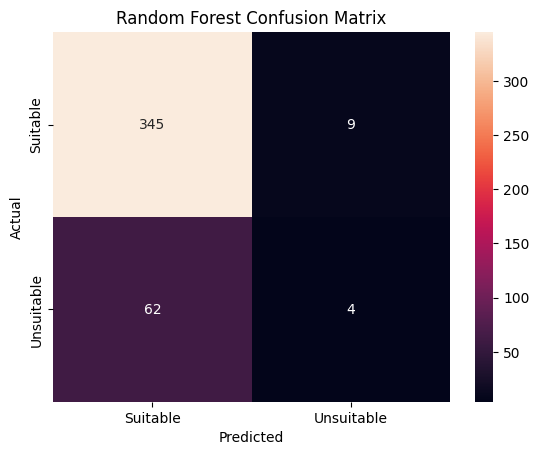

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

8.Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import numpy as np

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 8, 12, 16, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'max_depth': [None, 8, 12, 16, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 400, 500]},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
best_rf = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)


Best Parameters:
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 20}


In [ ]:
y_pred_tuned = best_rf.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))


Tuned Accuracy: 0.830952380952381


In [ ]:
import pandas as pd

importance = pd.Series(
    best_rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

print(importance)


rainfall          0.232862
temperature       0.152915
awc               0.146960
cec               0.137149
organic_carbon    0.122531
ph                0.108626
bulk_density      0.098958
dtype: float64
